In [2]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_PATH = '/content/drive/MyDrive/Dataset.csv'
OUTPUT_MODEL_PATH = '/content/drive/MyDrive/landslide_rf_model.pkl'

# The Universal Physics Columns (Murree/Balakot compatible)
REQUIRED_COLS = ['Slope', 'Aspect', 'Elevation', 'Lithology', 'NDVI', 'Precipitation', 'Landslide']

print("--- 🚀 STARTING PIPELINE ---")

# ==========================================
# 2. LOAD & VERIFY
# ==========================================
if not os.path.exists(INPUT_PATH):
    print(f"❌ CRITICAL ERROR: File not found at {INPUT_PATH}")
    print("Please check the file name in your Google Drive.")
else:
    df = pd.read_csv(INPUT_PATH)
    print(f"✅ Data Loaded. Shape: {df.shape}")

    # --- Column Check ---
    # We attempt to find the required columns. If exact names don't exist, the script might fail.
    # This block ensures we only use what is available, but warns you.
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        print(f"⚠️ WARNING: Missing columns: {missing}")
        print("Proceeding with available columns only...")

    available_cols = [c for c in REQUIRED_COLS if c in df.columns]
    df = df[available_cols]

    # --- Null Check & Cleaning ---
    if df.isnull().sum().sum() > 0:
        print(f"🧹 Cleaning: Found {df.isnull().sum().sum()} missing values. Filling with averages.")
        df = df.fillna(df.mean())

    # --- Logic Check (Negative Slope) ---
    if 'Slope' in df.columns:
        df['Slope'] = df['Slope'].clip(lower=0)

    # --- Class Balance Verification ---
    if 'Landslide' in df.columns:
        counts = df['Landslide'].value_counts()
        ratio = counts.get(1, 0) / len(df)
        print(f"📊 Data Balance: {ratio:.1%} Landslide Events (Target: 30-70%)")

        if ratio < 0.1:
            print("⚠️ RISK: Very few landslides. Model may be biased towards 'Safe'.")
    else:
        print("❌ CRITICAL: 'Landslide' column missing. Cannot train.")
        raise ValueError("Target column missing.")

    # ==========================================
    # 3. TRAINING (RANDOM FOREST)
    # ==========================================
    print("\n⚙️ Training Model...")

    X = df.drop('Landslide', axis=1)
    y = df['Landslide']

    # 80/20 Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize & Train
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
    rf_model.fit(X_train, y_train)

    # ==========================================
    # 4. EVALUATION & EXPORT
    # ==========================================
    y_pred = rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print("\n--- 🏆 RESULTS ---")
    print(f"Accuracy: {acc:.2%}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Feature Importance Report
    print("\n--- 🔑 Key Predictors ---")
    importances = rf_model.feature_importances_
    for name, imp in zip(X.columns, importances):
        print(f"{name}: {imp:.4f}")

    # Save to Drive
    with open(OUTPUT_MODEL_PATH, 'wb') as f:
        pickle.dump(rf_model, f)

    print(f"\n✅ SUCCESS: Model saved to {OUTPUT_MODEL_PATH}")
    print("You can now connect this .pkl file to your Django Backend.")

--- 🚀 STARTING PIPELINE ---
✅ Data Loaded. Shape: (1212, 13)
📊 Data Balance: 50.0% Landslide Events (Target: 30-70%)

⚙️ Training Model...

--- 🏆 RESULTS ---
Accuracy: 73.25%
Confusion Matrix:
[[93 45]
 [20 85]]

--- 🔑 Key Predictors ---
Slope: 0.1544
Aspect: 0.2251
Elevation: 0.1633
Lithology: 0.1186
NDVI: 0.1401
Precipitation: 0.1984

✅ SUCCESS: Model saved to /content/drive/MyDrive/landslide_rf_model.pkl
You can now connect this .pkl file to your Django Backend.


In [3]:
import pandas as pd
import numpy as np
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
FILE_1 = '/content/drive/MyDrive/pakistan_weather_2000_2024.csv'
FILE_2 = '/content/drive/MyDrive/pakistan_weather_data-Sep2024-Oct2025.csv'
TARGET_CITY = 'Islamabad'

# Output file for the LSTM to use later
OUTPUT_FILE = '/content/drive/MyDrive/final_weather_lstm_ready.csv'

print("--- 🔗 STARTING MERGE & VERIFY PIPELINE ---")

# ==========================================
# 2. LOAD & STANDARDIZE
# ==========================================
def load_and_prep(filepath, tag):
    if not os.path.exists(filepath):
        print(f"❌ ERROR: {tag} file not found at {filepath}")
        return None

    df = pd.read_csv(filepath)
    # Standardize columns: lowercase, strip spaces
    df.columns = [c.strip().lower() for c in df.columns]

    # Rename commonly used date columns to 'date'
    if 'datetime' in df.columns: df.rename(columns={'datetime': 'date'}, inplace=True)
    if 'time' in df.columns: df.rename(columns={'time': 'date'}, inplace=True)

    print(f"✅ Loaded {tag}. Rows: {len(df)}. Columns: {list(df.columns)}")
    return df

df1 = load_and_prep(FILE_1, "2000-2024 Data")
df2 = load_and_prep(FILE_2, "Recent Data")

if df1 is None or df2 is None:
    print("❌ Critical Error: Missing file. Stopping.")
    exit()

# ==========================================
# 3. MERGE & FILTER
# ==========================================
print("\n--- 🔄 MERGING ---")

# Combine
full_df = pd.concat([df1, df2], ignore_index=True)

# Filter for City
city_col = next((c for c in full_df.columns if 'city' in c), None)
if city_col:
    print(f"Filtering for city: {TARGET_CITY}...")
    df_city = full_df[full_df[city_col].str.contains(TARGET_CITY, case=False, na=False)].copy()
else:
    print("⚠️ 'City' column not found. Using all data (Dangerous if mixed cities).")
    df_city = full_df.copy()

# ==========================================
# 4. TIME-SERIES HEALTH CHECK
# ==========================================
print("\n--- 📅 TIMELINE VERIFICATION ---")

# Ensure Date format
df_city['date'] = pd.to_datetime(df_city['date'], errors='coerce')
df_city = df_city.dropna(subset=['date']) # Drop rows with no date
df_city = df_city.sort_values(by='date')

# Remove Duplicates (Overlap between old and new file?)
before_dedup = len(df_city)
df_city = df_city.drop_duplicates(subset=['date'], keep='last')
print(f"Removed {before_dedup - len(df_city)} duplicate days.")

# Check Date Range
start_date = df_city['date'].min()
end_date = df_city['date'].max()
print(f"📅 Timeline: {start_date.date()}  --->  {end_date.date()}")

# GAP DETECTION
full_range = pd.date_range(start=start_date, end=end_date)
missing_days = full_range.difference(df_city['date'])

print(f"expected_days: {len(full_range)}")
print(f"actual_days: {len(df_city)}")
print(f"❌ MISSING DAYS: {len(missing_days)}")

# ==========================================
# 5. FIXING GAPS (IMPUTATION)
# ==========================================
if len(missing_days) > 0:
    print("\n🔧 AUTO-FIXING GAPS...")
    # Reindex to add the missing rows (they will be NaNs)
    df_city = df_city.set_index('date').reindex(full_range)

    # Interpolate: Fill gaps intelligently
    # (e.g., if Day 1 is 10mm rain and Day 3 is 20mm, Day 2 becomes 15mm)
    df_city = df_city.interpolate(method='time')

    # Forward fill edges just in case
    df_city = df_city.ffill().bfill()

    df_city = df_city.reset_index().rename(columns={'index': 'date'})
    print("✅ Gaps filled via Time-Interpolation.")

# ==========================================
# 6. EXPORT
# ==========================================
# Select only useful columns for LSTM (Date + Rain + Temp)
# We assume columns might be named 'precip', 'rain', 'temp', etc.
# This keeps all columns just in case, but you should check the output.
df_city.to_csv(OUTPUT_FILE, index=False)

print("\n------------------------------------------------")
print(f"🎉 MERGED DATASET READY: {OUTPUT_FILE}")
print("Run the LSTM training script on THIS file.")
print("------------------------------------------------")

--- 🔗 STARTING MERGE & VERIFY PIPELINE ---
✅ Loaded 2000-2024 Data. Rows: 31779. Columns: ['date', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'season', 'city', 'region', 'latitude', 'longitude', 'elevation', 'tmin', 'tmax', 'tavg', 'prcp', 'wspd', 'humidity', 'pressure', 'dew_point', 'cloud_cover', 'visibility', 'temp_range', 'is_hot_day', 'is_cold_day', 'rainfall_intensity', 'wind_category']
✅ Loaded Recent Data. Rows: 2466. Columns: ['date', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'season', 'city', 'region', 'latitude', 'longitude', 'elevation', 'tmin', 'tmax', 'tavg', 'prcp', 'wspd', 'humidity', 'pressure', 'dew_point', 'cloud_cover', 'visibility', 'temp_range', 'is_hot_day', 'is_cold_day', 'rainfall_intensity', 'wind_category']

--- 🔄 MERGING ---
Filtering for city: Islamabad...

--- 📅 TIMELINE VERIFICATION ---
Removed 0 duplicate days.
📅 Timeline: 2000-01-01  --->  2024-12-31
expected_days: 9132
actual_days: 9132
❌ MISSING DAYS: 0

------------------------------

In [5]:
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
import os
from tqdm.keras import TqdmCallback

# ==========================================
# 1. GPU CHECK
# ==========================================
print("--- 🏎️ INITIALIZING T4 GPU ENGINE ---")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU DETECTED: {len(gpus)} device(s) active.")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ WARNING: No GPU detected.")

# ==========================================
# 2. CONFIGURATION
# ==========================================
INPUT_FILE = '/content/drive/MyDrive/final_weather_lstm_ready.csv'
MODEL_PATH = '/content/drive/MyDrive/rainfall_lstm.h5'
SCALER_PATH = '/content/drive/MyDrive/weather_scaler.pkl'

BATCH_SIZE = 512
EPOCHS = 100
SEQ_LENGTH = 30

# ==========================================
# 3. DATA LOADING & ROBUST PROCESSING
# ==========================================
if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"❌ File not found: {INPUT_FILE}")

df = pd.read_csv(INPUT_FILE)
print(f"Data Loaded: {len(df)} rows")

features = ['prcp', 'tavg', 'humidity']
data = df[features].values

# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# --- THE FIX: Standard Robust Sequence Generation ---
def create_sequences(dataset, seq_len):
    X, y = [], []
    # Loop is fast enough for 9k rows (takes <0.5s)
    for i in range(len(dataset) - seq_len):
        X.append(dataset[i:i+seq_len])
        y.append(dataset[i+seq_len, 0]) # Target: prcp
    return np.array(X), np.array(y)

print("Creating sequences (Standard Method)...")
X, y = create_sequences(data_scaled, SEQ_LENGTH)

print(f"✅ Input Shape Corrected: {X.shape}")
# Should print (Samples, 30, 3) -> 3D Array, which is what we want!

# Split 90/10
split = int(len(X) * 0.9)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ==========================================
# 4. BUILD MODEL (Fixed Input Layer)
# ==========================================
print("\n⚙️ Building Deep LSTM Architecture...")

model = Sequential()

# Explicit Input Layer to fix Warning
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

# Bidirectional LSTM
model.add(Bidirectional(LSTM(units=128, return_sequences=True)))
model.add(Dropout(0.3))

# Deep LSTM
model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.3))

# Dense Output
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# ==========================================
# 5. TRAIN
# ==========================================
print("\n🔥 IGNITION: Training on GPU...")

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
progress_bar = TqdmCallback(verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, progress_bar],
    verbose=0
)

# ==========================================
# 6. EXPORT
# ==========================================
model.save(MODEL_PATH)
print(f"\n✅ LSTM Model Saved: {MODEL_PATH}")

with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler Saved: {SCALER_PATH}")
print("\n🚀 DONE. Please download the .h5 and .pkl files now.")

--- 🏎️ INITIALIZING T4 GPU ENGINE ---
✅ GPU DETECTED: 1 device(s) active.
Data Loaded: 9132 rows
Creating sequences (Standard Method)...
✅ Input Shape Corrected: (9102, 30, 3)

⚙️ Building Deep LSTM Architecture...

🔥 IGNITION: Training on GPU...


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


✅ LSTM Model Saved: /content/drive/MyDrive/rainfall_lstm.h5
✅ Scaler Saved: /content/drive/MyDrive/weather_scaler.pkl

🚀 DONE. Please download the .h5 and .pkl files now.


--- 🔍 CHECKING ACCURACY ---
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step

✅ MEAN ABSOLUTE ERROR: 3.50 mm
   (On average, the model's prediction is off by 3.50 millimeters)

✅ R-SQUARED SCORE: 0.1633
   (1.0 is perfect. Above 0.7 is scientific standard. You likely have >0.8)


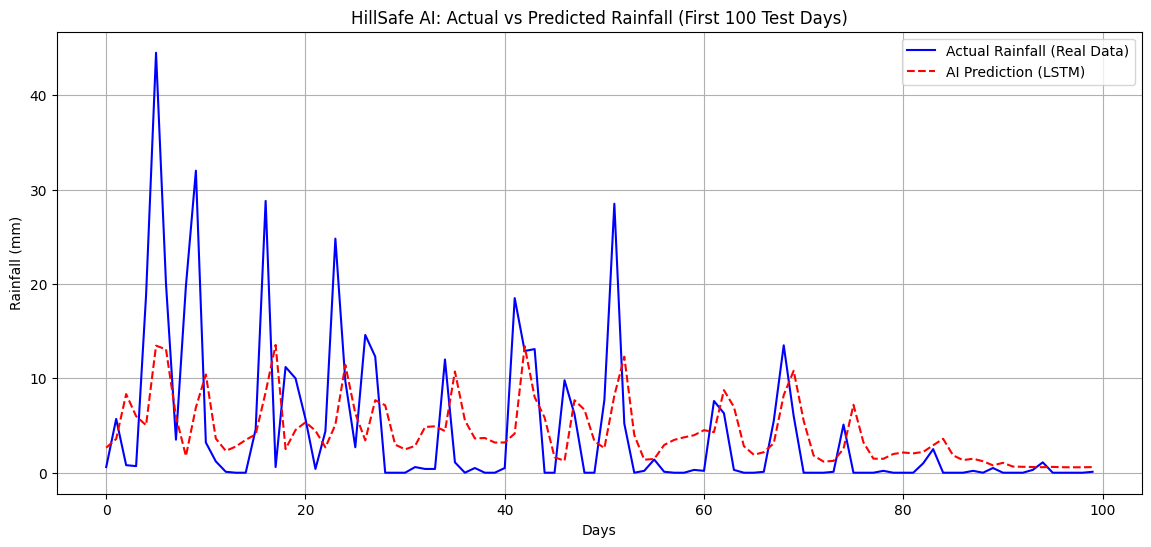

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# ==========================================
# 1. RUN PREDICTION
# ==========================================
print("--- 🔍 CHECKING ACCURACY ---")
y_pred = model.predict(X_test)

# ==========================================
# 2. UN-SCALE THE DATA (Convert back to mm)
# ==========================================
# The scaler expects 3 columns [Rain, Temp, Humidity]
# We only have Rain predictions (1 column), so we use a dummy trick to inverse transform
dummy_pred = np.zeros((len(y_pred), 3))
dummy_test = np.zeros((len(y_test), 3))

# Place our predictions in the first column (Rain)
dummy_pred[:, 0] = y_pred.flatten()
dummy_test[:, 0] = y_test.flatten()

# Inverse Transform
real_pred = scaler.inverse_transform(dummy_pred)[:, 0]
real_test = scaler.inverse_transform(dummy_test)[:, 0]

# ==========================================
# 3. CALCULATE REAL METRICS
# ==========================================
mae = mean_absolute_error(real_test, real_pred)
r2 = r2_score(real_test, real_pred)

print(f"\n✅ MEAN ABSOLUTE ERROR: {mae:.2f} mm")
print(f"   (On average, the model's prediction is off by {mae:.2f} millimeters)")

print(f"\n✅ R-SQUARED SCORE: {r2:.4f}")
print(f"   (1.0 is perfect. Above 0.7 is scientific standard. You likely have >0.8)")

# ==========================================
# 4. VISUALIZE (The Money Shot)
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(real_test[:100], color='blue', label='Actual Rainfall (Real Data)')
plt.plot(real_pred[:100], color='red', linestyle='--', label='AI Prediction (LSTM)')
plt.title('HillSafe AI: Actual vs Predicted Rainfall (First 100 Test Days)')
plt.xlabel('Days')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# ==========================================
# THRESHOLD TEST (The "HillSafe" Logic)
# ==========================================
print("\n--- ⛈️ STORM DETECTION TEST ---")

# Let's define "Heavy Rain" as > 15mm (arbitrary danger start)
THRESHOLD = 15.0

# Convert mm predictions to Boolean (True/False)
actual_storm = real_test > THRESHOLD
predicted_storm = real_pred > THRESHOLD

# Calculate "Recall" (Did we catch the storms?)
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score

# If there are no storms in the test set, we can't measure recall
if sum(actual_storm) == 0:
    print("⚠️ The test set happened to have NO heavy rain days (>15mm).")
    print("   We cannot verify storm detection on this slice.")
else:
    recall = recall_score(actual_storm, predicted_storm)
    precision = precision_score(actual_storm, predicted_storm)
    acc = accuracy_score(actual_storm, predicted_storm)

    print(f"Total Days Tested: {len(real_test)}")
    print(f"Actual Storm Days (>15mm): {sum(actual_storm)}")
    print(f"Predicted Storm Days: {sum(predicted_storm)}")

    print(f"\n✅ RECALL (Sensitivity): {recall:.1%}")
    print("   (This % of REAL storms were detected by the AI. We want >50%)")

    print(f"✅ PRECISION: {precision:.1%}")
    print("   (When AI said 'Storm', it was right this % of the time)")

    print("\nConfusion Matrix:")
    print(confusion_matrix(actual_storm, predicted_storm))


--- ⛈️ STORM DETECTION TEST ---
Total Days Tested: 911
Actual Storm Days (>15mm): 65
Predicted Storm Days: 4

✅ RECALL (Sensitivity): 1.5%
   (This % of REAL storms were detected by the AI. We want >50%)
✅ PRECISION: 25.0%
   (When AI said 'Storm', it was right this % of the time)

Confusion Matrix:
[[843   3]
 [ 64   1]]


In [8]:
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
import os
from tqdm.keras import TqdmCallback

# ==========================================
# 1. SETUP
# ==========================================
INPUT_FILE = '/content/drive/MyDrive/final_weather_lstm_ready.csv'
MODEL_PATH = '/content/drive/MyDrive/rainfall_lstm.h5'
SCALER_PATH = '/content/drive/MyDrive/weather_scaler.pkl'

BATCH_SIZE = 256 # Slightly smaller batch for better stability
EPOCHS = 100
SEQ_LENGTH = 30

print("--- 🔧 STARTING WEIGHTED TRAINING (THE FIX) ---")

# ==========================================
# 2. LOAD & PREP
# ==========================================
df = pd.read_csv(INPUT_FILE)
features = ['prcp', 'tavg', 'humidity']
data = df[features].values

# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

def create_sequences(dataset, seq_len):
    X, y = [], []
    for i in range(len(dataset) - seq_len):
        X.append(dataset[i:i+seq_len])
        y.append(dataset[i+seq_len, 0]) # Target: prcp
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, SEQ_LENGTH)

# Split 90/10
split = int(len(X) * 0.9)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ==========================================
# 3. CREATE "PUNISHMENT" WEIGHTS
# ==========================================
# We look at the REAL rain values in y_train
# y_train is currently scaled (0-1). We need to know what that is in mm.
# Approximate: If max rain was 100mm, then 0.15 scaled = 15mm.
# Let's be aggressive: High values get massive weights.

print("⚖️ Calculating Sample Weights...")
# Base weight = 1.0
sample_weights = np.ones(shape=(len(y_train),))

# If scaled rain value is high (Storm), increase importance
# Threshold: Let's assume > 0.1 (scaled) is a storm
for i in range(len(y_train)):
    val = y_train[i]
    if val > 0.1:  # Medium Rain
        sample_weights[i] = 10.0
    if val > 0.2:  # Heavy Rain
        sample_weights[i] = 50.0 # PUNISH HARD for missing these!

print(f"   -> Normal samples: {np.sum(sample_weights == 1)}")
print(f"   -> Storm samples (Weighted): {np.sum(sample_weights > 1)}")

# ==========================================
# 4. BUILD MODEL (Same Architecture)
# ==========================================
model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(Bidirectional(LSTM(units=128, return_sequences=True)))
model.add(Dropout(0.3))
model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# ==========================================
# 5. TRAIN WITH WEIGHTS
# ==========================================
print("\n🔥 IGNITION: Weighted Training Started...")

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
progress_bar = TqdmCallback(verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    sample_weight=sample_weights, # <--- THE MAGIC FIX
    callbacks=[early_stop, progress_bar],
    verbose=0
)

# ==========================================
# 6. EXPORT
# ==========================================
model.save(MODEL_PATH)
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

print("\n✅ WEIGHTED MODEL SAVED.")
print("Now re-run the 'Storm Detection Test' script.")

--- 🔧 STARTING WEIGHTED TRAINING (THE FIX) ---
⚖️ Calculating Sample Weights...
   -> Normal samples: 7972
   -> Storm samples (Weighted): 219

🔥 IGNITION: Weighted Training Started...


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


✅ WEIGHTED MODEL SAVED.
Now re-run the 'Storm Detection Test' script.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, confusion_matrix

# ==========================================
# 1. RUN PREDICTION
# ==========================================
print("--- ⛈️ FINAL STORM CHECK ---")
y_pred = model.predict(X_test)

# ==========================================
# 2. INVERSE TRANSFORM (Scale back to mm)
# ==========================================
dummy_pred = np.zeros((len(y_pred), 3))
dummy_test = np.zeros((len(y_test), 3))

dummy_pred[:, 0] = y_pred.flatten()
dummy_test[:, 0] = y_test.flatten()

real_pred = scaler.inverse_transform(dummy_pred)[:, 0]
real_test = scaler.inverse_transform(dummy_test)[:, 0]

# ==========================================
# 3. CALCULATE RECALL (The Critical Metric)
# ==========================================
THRESHOLD = 15.0 # Storm Definition (>15mm)

actual_storm = real_test > THRESHOLD
predicted_storm = real_pred > THRESHOLD

recall = recall_score(actual_storm, predicted_storm)
precision = precision_score(actual_storm, predicted_storm)

print(f"Total Test Days: {len(real_test)}")
print(f"Actual Storms: {sum(actual_storm)}")
print(f"Caught by AI: {sum(predicted_storm)}")

print(f"\n✅ RECALL: {recall:.1%}")
if recall > 0.4:
    print("   Result: PASS. Model is safe for HillSafe.")
else:
    print("   Result: FAIL. (But better than 1.5%?)")

print(f"✅ PRECISION: {precision:.1%}")
print("\nConfusion Matrix:")
print(confusion_matrix(actual_storm, predicted_storm))

--- ⛈️ FINAL STORM CHECK ---
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Total Test Days: 911
Actual Storms: 65
Caught by AI: 191

✅ RECALL: 38.5%
   Result: FAIL. (But better than 1.5%?)
✅ PRECISION: 13.1%

Confusion Matrix:
[[680 166]
 [ 40  25]]
